# Day 13 (Light) — First look at CARD - Pandase library

In [1]:
import json

with open("data/card/card.json") as f:
    card = json.load(f)

print(f"Total entries in CARD: {len(card)}")

# Look at the structure of one entry
sample_key = list(card.keys())[3]  # skip the first few metadata keys
print(sample_key, "->", type(card[sample_key]))

Total entries in CARD: 6445
7 -> <class 'dict'>


# Day 15 (Full) — Pandas mechanics, on your own real data

In [1]:
import pandas as pd 

In [2]:

# Replace "aro_index.tsv" below with whatever filename you actually saw in `ls`
df = pd.read_csv("data/card/aro_index.tsv", sep="\t")
print(df.shape)
df.head()
print(df.columns.tolist())

(6445, 12)
['ARO Accession', 'CVTERM ID', 'Model Sequence ID', 'Model ID', 'Model Name', 'ARO Name', 'Protein Accession', 'DNA Accession', 'AMR Gene Family', 'Drug Class', 'Resistance Mechanism', 'CARD Short Name']


In [10]:
df.info()    # column types and missing values

<class 'pandas.DataFrame'>
RangeIndex: 6445 entries, 0 to 6444
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ARO Accession         6445 non-null   str  
 1   CVTERM ID             6445 non-null   int64
 2   Model Sequence ID     6445 non-null   int64
 3   Model ID              6445 non-null   int64
 4   Model Name            6445 non-null   str  
 5   ARO Name              6445 non-null   str  
 6   Protein Accession     6358 non-null   str  
 7   DNA Accession         6445 non-null   str  
 8   AMR Gene Family       6445 non-null   str  
 9   Drug Class            6445 non-null   str  
 10  Resistance Mechanism  6445 non-null   str  
 11  CARD Short Name       6445 non-null   str  
dtypes: int64(3), str(9)
memory usage: 604.3 KB


In [4]:
df["Drug Class"].value_counts()

Drug Class
cephalosporin                                                                                                                                                                                                                                                                               943
carbapenem;penicillin beta-lactam                                                                                                                                                                                                                                                           821
carbapenem;cephalosporin;monobactam                                                                                                                                                                                                                                                         638
penicillin beta-lactam                                                                                                       

In [6]:
df["AMR Gene Family"].value_counts()

AMR Gene Family
PDC beta-lactamase                                                       639
OXA beta-lactamase;OXA-51-like beta-lactamase                            383
ADC beta-lactamases pending classification for carbapenemase activity    274
CTX-M beta-lactamase                                                     267
KPC beta-lactamase                                                       229
                                                                        ... 
BlaA beta-lactamase                                                        1
YEM beta-lactamase                                                         1
YOC beta-lactamase                                                         1
YRC beta-lactamase                                                         1
ZOG beta-lactamase                                                         1
Name: count, Length: 540, dtype: int64

In [7]:
df["ARO Name"].value_counts()

ARO Name
CMY-106                                                                    2
CMY-131                                                                    2
Escherichia coli cyaA with mutation conferring resistance to fosfomycin    2
Escherichia coli uhpA with mutation conferring resistance to fosfomycin    2
MexR                                                                       2
                                                                          ..
ykkD                                                                       1
YOC-1                                                                      1
YojI                                                                       1
YRC-1                                                                      1
ZOG-1                                                                      1
Name: count, Length: 6440, dtype: int64

In [13]:

df[df["Drug Class"].str.contains("fluoroquinolone", case= False, na=False)]

'''
Go to the DataFrame df, look at the "Drug Class" column, check each cell to see if its text contains "fluoroquinolone" (ignoring uppercase/lowercase differences). Treat missing values as not containing the text, then return only the rows where the text is found.


'''

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
58,ARO:3002547,38947,6152,1678,AAC(6')-Ib-cr1,AAC(6')-Ib-cr1,WP_071846215.1,NG_052213.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr1
59,ARO:3007770,46553,8755,6020,aac(6')-Ib-cr10,aac(6')-Ib-cr10,WP_124042715.1,NG_067968.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr10
60,ARO:3007771,46554,8756,6021,aac(6')-Ib-cr11,aac(6')-Ib-cr11,WP_159241551.1,NG_067969.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr11
61,ARO:3005112,43327,8752,3840,AAC(6')-Ib-cr3,AAC(6')-Ib-cr3,WP_071766621.1,NG_052123.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr3
62,ARO:3005114,43329,8753,3841,AAC(6')-Ib-cr4,AAC(6')-Ib-cr4,WP_065187000.1,NG_052463.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr4
...,...,...,...,...,...,...,...,...,...,...,...,...
6191,ARO:3004059,41125,5520,2691,Type A NfxB,Type A NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;cephalosporin;diamino...,antibiotic efflux,Type_A_NfxB
6192,ARO:3004060,41127,5519,2693,Type B NfxB,Type B NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,Type_B_NfxB
6194,ARO:3003305,39889,5887,2148,Ureaplasma urealyticum gyrB conferring resista...,Ureaplasma urealyticum gyrB conferring resista...,WP_004025678.1,NC_011374.1,fluoroquinolone resistant gyrB,aminocoumarin antibiotic;fluoroquinolone antib...,antibiotic target alteration,Uure_gyrB_FLO
6195,ARO:3003309,39893,5888,2104,Ureaplasma urealyticum parC conferring resista...,Ureaplasma urealyticum parC conferring resista...,WP_010891786.1,NC_002162.1,fluoroquinolone resistant parC,fluoroquinolone antibiotic,antibiotic target alteration,Uure_parC_FLO


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6445 entries, 0 to 6444
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ARO Accession         6445 non-null   str  
 1   CVTERM ID             6445 non-null   int64
 2   Model Sequence ID     6445 non-null   int64
 3   Model ID              6445 non-null   int64
 4   Model Name            6445 non-null   str  
 5   ARO Name              6445 non-null   str  
 6   Protein Accession     6358 non-null   str  
 7   DNA Accession         6445 non-null   str  
 8   AMR Gene Family       6445 non-null   str  
 9   Drug Class            6445 non-null   str  
 10  Resistance Mechanism  6445 non-null   str  
 11  CARD Short Name       6445 non-null   str  
dtypes: int64(3), str(9)
memory usage: 604.3 KB


In [19]:
df[df["Resistance Mechanism"].str.contains("antibiotic inactivation", case= False, na=False)]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id
5,ARO:3002527,38927,5510,2832,AAC(2')-Ie,AAC(2')-Ie,CAC32082.1,AL583926.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ie
...,...,...,...,...,...,...,...,...,...,...,...,...
6436,ARO:3003558,40163,3318,980,y56 beta-lactamase,y56 beta-lactamase,AAX55643.1,AY954728.1,BlaA beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,Yent_y56
6438,ARO:3007005,45467,8098,5723,YEM-1,YEM-1,WP_004874166.1,NG_070759.1,YEM beta-lactamase,carbapenem,antibiotic inactivation,YEM-1
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1


In [21]:
print(df.columns.tolist())

['ARO Accession', 'CVTERM ID', 'Model Sequence ID', 'Model ID', 'Model Name', 'ARO Name', 'Protein Accession', 'DNA Accession', 'AMR Gene Family', 'Drug Class', 'Resistance Mechanism', 'CARD Short Name']


In [28]:
df_fluoroquinolone =df[df["Drug Class"].str.contains("fluoroquinolone", case = False, na = False)]

df_fluoroquinolone
df_fluoroquinolone.reset_index()

,index,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,58,ARO:3002547,38947,6152,1678,AAC(6')-Ib-cr1,AAC(6')-Ib-cr1,WP_071846215.1,NG_052213.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr1
1,59,ARO:3007770,46553,8755,6020,aac(6')-Ib-cr10,aac(6')-Ib-cr10,WP_124042715.1,NG_067968.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr10
2,60,ARO:3007771,46554,8756,6021,aac(6')-Ib-cr11,aac(6')-Ib-cr11,WP_159241551.1,NG_067969.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr11
3,61,ARO:3005112,43327,8752,3840,AAC(6')-Ib-cr3,AAC(6')-Ib-cr3,WP_071766621.1,NG_052123.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr3
4,62,ARO:3005114,43329,8753,3841,AAC(6')-Ib-cr4,AAC(6')-Ib-cr4,WP_065187000.1,NG_052463.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,6191,ARO:3004059,41125,5520,2691,Type A NfxB,Type A NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;cephalosporin;diamino...,antibiotic efflux,Type_A_NfxB
309,6192,ARO:3004060,41127,5519,2693,Type B NfxB,Type B NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,Type_B_NfxB
310,6194,ARO:3003305,39889,5887,2148,Ureaplasma urealyticum gyrB conferring resista...,Ureaplasma urealyticum gyrB conferring resista...,WP_004025678.1,NC_011374.1,fluoroquinolone resistant gyrB,aminocoumarin antibiotic;fluoroquinolone antib...,antibiotic target alteration,Uure_gyrB_FLO
311,6195,ARO:3003309,39893,5888,2104,Ureaplasma urealyticum parC conferring resista...,Ureaplasma urealyticum parC conferring resista...,WP_010891786.1,NC_002162.1,fluoroquinolone resistant parC,fluoroquinolone antibiotic,antibiotic target alteration,Uure_parC_FLO


In [30]:
df_fluoroquinolone =df[df["Drug Class"].str.contains("fluoroquinolone", case = False, na = False)]

df_fluoroquinolone
df_fluoroquinolone.reset_index(drop=True) # discarding the old index numbers. 

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3002547,38947,6152,1678,AAC(6')-Ib-cr1,AAC(6')-Ib-cr1,WP_071846215.1,NG_052213.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr1
1,ARO:3007770,46553,8755,6020,aac(6')-Ib-cr10,aac(6')-Ib-cr10,WP_124042715.1,NG_067968.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr10
2,ARO:3007771,46554,8756,6021,aac(6')-Ib-cr11,aac(6')-Ib-cr11,WP_159241551.1,NG_067969.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr11
3,ARO:3005112,43327,8752,3840,AAC(6')-Ib-cr3,AAC(6')-Ib-cr3,WP_071766621.1,NG_052123.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr3
4,ARO:3005114,43329,8753,3841,AAC(6')-Ib-cr4,AAC(6')-Ib-cr4,WP_065187000.1,NG_052463.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr4
...,...,...,...,...,...,...,...,...,...,...,...,...
308,ARO:3004059,41125,5520,2691,Type A NfxB,Type A NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;cephalosporin;diamino...,antibiotic efflux,Type_A_NfxB
309,ARO:3004060,41127,5519,2693,Type B NfxB,Type B NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,Type_B_NfxB
310,ARO:3003305,39889,5887,2148,Ureaplasma urealyticum gyrB conferring resista...,Ureaplasma urealyticum gyrB conferring resista...,WP_004025678.1,NC_011374.1,fluoroquinolone resistant gyrB,aminocoumarin antibiotic;fluoroquinolone antib...,antibiotic target alteration,Uure_gyrB_FLO
311,ARO:3003309,39893,5888,2104,Ureaplasma urealyticum parC conferring resista...,Ureaplasma urealyticum parC conferring resista...,WP_010891786.1,NC_002162.1,fluoroquinolone resistant parC,fluoroquinolone antibiotic,antibiotic target alteration,Uure_parC_FLO


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6445 entries, 0 to 6444
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ARO Accession         6445 non-null   str  
 1   CVTERM ID             6445 non-null   int64
 2   Model Sequence ID     6445 non-null   int64
 3   Model ID              6445 non-null   int64
 4   Model Name            6445 non-null   str  
 5   ARO Name              6445 non-null   str  
 6   Protein Accession     6358 non-null   str  
 7   DNA Accession         6445 non-null   str  
 8   AMR Gene Family       6445 non-null   str  
 9   Drug Class            6445 non-null   str  
 10  Resistance Mechanism  6445 non-null   str  
 11  CARD Short Name       6445 non-null   str  
dtypes: int64(3), str(9)
memory usage: 604.3 KB


In [33]:
df.head()

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id


In [34]:
df.head(10)

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id
5,ARO:3002527,38927,5510,2832,AAC(2')-Ie,AAC(2')-Ie,CAC32082.1,AL583926.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ie
6,ARO:3004628,42613,5361,3327,AAC(2')-IIa,AAC(2')-IIa,BAM16262.1,AB669090.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIa
7,ARO:3003988,40870,3860,2524,AAC(2')-IIb,AAC(2')-IIb,APB03221.1,KX531051.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIb
8,ARO:3002528,38928,8360,39,AAC(3)-Ia,AAC(3)-Ia,AAG15269.1,U12338.3,AAC(3),aminoglycoside antibiotic,antibiotic inactivation,AAC(3)-Ia
9,ARO:3002530,38930,224,575,AAC(3)-Ib,AAC(3)-Ib,AAA88422.1,L06157.1,AAC(3),aminoglycoside antibiotic,antibiotic inactivation,AAC(3)-Ib


In [35]:
df.tail()

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1
6444,ARO:3007006,45468,8099,5724,ZOG-1,ZOG-1,WP_013992183.1,NG_057434.1,ZOG beta-lactamase,carbapenem,antibiotic inactivation,ZOG-1


In [36]:
df.sample(5)

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
5449,ARO:3002795,39229,296,60,QnrS6,QnrS6,AEG74318.1,HQ631376.1,quinolone resistance protein (qnr),fluoroquinolone antibiotic,antibiotic target protection,QnrS6
2185,ARO:3005468,43930,7063,4688,IMP-61,IMP-61,WP_065419570.1,NG_051166.1,IMP beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,IMP-61
5272,ARO:3002363,38763,4747,919,PER-1,PER-1,CAA79968.1,Z21957.1,PER beta-lactamase,carbapenem;cephalosporin;monobactam;penicillin...,antibiotic inactivation,PER-1
4800,ARO:3006660,45122,7795,5420,PDC-288,PDC-288,WP_111672899.1,NG_060557.1,PDC beta-lactamase,carbapenem;cephalosporin;monobactam,antibiotic inactivation,PDC-288
5040,ARO:3008851,47643,11096,8269,PDC-504,PDC-504,UGW32405.1,OL774884.1,PDC beta-lactamase,carbapenem;cephalosporin;monobactam,antibiotic inactivation,PDC-504


In [38]:
df.shape

(6445, 12)

In [39]:
df.index


RangeIndex(start=0, stop=6445, step=1)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6445 entries, 0 to 6444
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ARO Accession         6445 non-null   str  
 1   CVTERM ID             6445 non-null   int64
 2   Model Sequence ID     6445 non-null   int64
 3   Model ID              6445 non-null   int64
 4   Model Name            6445 non-null   str  
 5   ARO Name              6445 non-null   str  
 6   Protein Accession     6358 non-null   str  
 7   DNA Accession         6445 non-null   str  
 8   AMR Gene Family       6445 non-null   str  
 9   Drug Class            6445 non-null   str  
 10  Resistance Mechanism  6445 non-null   str  
 11  CARD Short Name       6445 non-null   str  
dtypes: int64(3), str(9)
memory usage: 604.3 KB


In [41]:
df.describe()

,CVTERM ID,Model Sequence ID,Model ID
count,6445.000000,6445.000000,6445.000000
mean,42565.820171,6163.509542,3969.479752
std,3571.126733,3354.272743,2538.758819
min,36014.000000,1.000000,1.000000
25%,38914.000000,3464.000000,1631.000000
50%,43574.000000,6714.000000,4027.000000
75%,45371.000000,8408.000000,5647.000000
max,48038.000000,11361.000000,8524.000000


In [43]:
#Select columns 
df[["ARO Name", "Drug Class"]]

,ARO Name,Drug Class
0,23S rRNA (adenine(2058)-N(6))-methyltransferas...,lincosamide antibiotic;macrolide antibiotic;st...
1,AAC(2')-Ia,aminoglycoside antibiotic
2,AAC(2')-Ib,aminoglycoside antibiotic
3,AAC(2')-Ic,aminoglycoside antibiotic
4,AAC(2')-Id,aminoglycoside antibiotic
...,...,...
6440,ykkD,aminoglycoside antibiotic;phenicol antibiotic;...
6441,YOC-1,cephalosporin
6442,YojI,peptide antibiotic
6443,YRC-1,cephalosporin;penicillin beta-lactam


In [44]:
# 3. Select Rows 
df.iloc[:10]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id
5,ARO:3002527,38927,5510,2832,AAC(2')-Ie,AAC(2')-Ie,CAC32082.1,AL583926.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ie
6,ARO:3004628,42613,5361,3327,AAC(2')-IIa,AAC(2')-IIa,BAM16262.1,AB669090.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIa
7,ARO:3003988,40870,3860,2524,AAC(2')-IIb,AAC(2')-IIb,APB03221.1,KX531051.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIb
8,ARO:3002528,38928,8360,39,AAC(3)-Ia,AAC(3)-Ia,AAG15269.1,U12338.3,AAC(3),aminoglycoside antibiotic,antibiotic inactivation,AAC(3)-Ia
9,ARO:3002530,38930,224,575,AAC(3)-Ib,AAC(3)-Ib,AAA88422.1,L06157.1,AAC(3),aminoglycoside antibiotic,antibiotic inactivation,AAC(3)-Ib


In [46]:
df.iloc[-10:]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
6435,ARO:3007435,46193,8652,5933,WUS-1,WUS-1,UPP01678.1,OL872181.1,WUS beta-lactamase,carbapenem;penicillin beta-lactam,antibiotic inactivation,WUS-1
6436,ARO:3003558,40163,3318,980,y56 beta-lactamase,y56 beta-lactamase,AAX55643.1,AY954728.1,BlaA beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,Yent_y56
6437,ARO:3005040,43238,6076,3783,YajC,YajC,TKW44661.1,VAOQ01003483.1,resistance-nodulation-cell division (RND) anti...,cephalosporin;disinfecting agents and antisept...,antibiotic efflux,YajC
6438,ARO:3007005,45467,8098,5723,YEM-1,YEM-1,WP_004874166.1,NG_070759.1,YEM beta-lactamase,carbapenem,antibiotic inactivation,YEM-1
6439,ARO:3003063,39497,489,1826,ykkC,ykkC,CAB13166.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkC
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1
6444,ARO:3007006,45468,8099,5724,ZOG-1,ZOG-1,WP_013992183.1,NG_057434.1,ZOG beta-lactamase,carbapenem,antibiotic inactivation,ZOG-1


In [47]:
df.iloc[100:250]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
100,ARO:3004692,42744,5586,3398,aadA10,aadA10,AAL36430.1,U37105.2,ANT(3''),aminoglycoside antibiotic,antibiotic inactivation,aadA10
101,ARO:3002611,39011,13,1772,aadA11,aadA11,AAV32840.1,AY758206.1,ANT(3''),aminoglycoside antibiotic,antibiotic inactivation,aadA11
102,ARO:3002612,39012,57,149,aadA12,aadA12,ACJ47200.1,FJ381668.1,ANT(3''),aminoglycoside antibiotic,antibiotic inactivation,aadA12
103,ARO:3002613,39013,5258,2087,aadA13,aadA13,ABW91178.1,EU746499.1,ANT(3''),aminoglycoside antibiotic,antibiotic inactivation,aadA13
104,ARO:3002614,39014,4676,1839,aadA14,aadA14,CAI57696.1,AJ884726.1,ANT(3''),aminoglycoside antibiotic,antibiotic inactivation,aadA14
...,...,...,...,...,...,...,...,...,...,...,...,...
245,ARO:3001828,38228,1990,1645,ACT-23,ACT-23,AGU38146.1,KF515536.1,ACT beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,ACT-23
246,ARO:3001844,38244,779,1929,ACT-24,ACT-24,AHL39336.1,KJ207207.1,ACT beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,ACT-24
247,ARO:3001845,38245,861,433,ACT-25,ACT-25,AHL39338.1,KJ207208.1,ACT beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,ACT-25
248,ARO:3001847,38247,941,1484,ACT-27,ACT-27,AHL39340.1,KJ207209.1,ACT beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,ACT-27


In [51]:
# 4. Filtering 
# all beta lactam genes. 

df[df["Drug Class"].str.contains("beta-lactam", case = False, na = False)]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
128,ARO:3003942,40695,4691,2416,abcA,abcA,XP_753111.1,XM_748018.1,ATP-binding cassette (ABC) antibiotic efflux pump,cephalosporin;moenomycin antibiotic;penicillin...,antibiotic efflux,abcA
131,ARO:3001815,38215,856,1663,ACC-1,ACC-1,CAB46491.1,AJ133121.1,ACC beta-lactamase,cephalosporin;monobactam;penicillin beta-lactam,antibiotic inactivation,ACC-1
132,ARO:3006228,44690,6498,4123,ACC-1a,ACC-1a,WP_039189232.1,NG_048589.1,ACC beta-lactamase,cephalosporin;monobactam;penicillin beta-lactam,antibiotic inactivation,ACC-1a
133,ARO:3006229,44691,6499,4124,ACC-1b,ACC-1b,WP_063857697.1,NG_048590.1,ACC beta-lactamase,cephalosporin;monobactam;penicillin beta-lactam,antibiotic inactivation,ACC-1b
134,ARO:3006230,44692,6500,4125,ACC-1c,ACC-1c,WP_063857698.1,NG_048591.1,ACC beta-lactamase,cephalosporin;monobactam;penicillin beta-lactam,antibiotic inactivation,ACC-1c
...,...,...,...,...,...,...,...,...,...,...,...,...
6431,ARO:3005015,43204,6048,3758,VMB-1,VMB-1,QGQ32905.1,MN719868.1,VMB beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,VMB-1
6435,ARO:3007435,46193,8652,5933,WUS-1,WUS-1,UPP01678.1,OL872181.1,WUS beta-lactamase,carbapenem;penicillin beta-lactam,antibiotic inactivation,WUS-1
6436,ARO:3003558,40163,3318,980,y56 beta-lactamase,y56 beta-lactamase,AAX55643.1,AY954728.1,BlaA beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,Yent_y56
6437,ARO:3005040,43238,6076,3783,YajC,YajC,TKW44661.1,VAOQ01003483.1,resistance-nodulation-cell division (RND) anti...,cephalosporin;disinfecting agents and antisept...,antibiotic efflux,YajC


In [53]:
# Genes with missing protein accession 

df[df["Protein Accession"].isna()]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
861,ARO:3003504,40106,3268,2143,Borreliella burgdorferi 16S rRNA mutation conf...,Borreliella burgdorferi 16S rRNA mutation conf...,NaN,NR_044732.2,16s rRNA with mutation conferring resistance t...,aminoglycoside antibiotic;glycopeptide antibio...,antibiotic target alteration,Bbur_16S_GEN
862,ARO:3003503,40105,8691,2127,Borreliella burgdorferi 16S rRNA mutation conf...,Borreliella burgdorferi 16S rRNA mutation conf...,NaN,NZ_ABCW02000003.1,16s rRNA with mutation conferring resistance t...,aminoglycoside antibiotic;glycopeptide antibio...,antibiotic target alteration,Bbur_16S_KAN
863,ARO:3003502,40104,3267,2154,Borreliella burgdorferi 16S rRNA mutation conf...,Borreliella burgdorferi 16S rRNA mutation conf...,NaN,NR_044732.2,16s rRNA with mutation conferring resistance t...,aminoglycoside antibiotic;glycopeptide antibio...,antibiotic target alteration,Bbur_16S_SPT
866,ARO:3004133,41260,4183,2833,Brachyspira hyodysenteriae 23S rRNA with mutat...,Brachyspira hyodysenteriae 23S rRNA with mutat...,NaN,NZ_CP015910.2,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Bhyo_23S_TYL
880,ARO:3004546,42445,5105,3252,Campylobacter jejuni 23S rRNA with mutation co...,Campylobacter jejuni 23S rRNA with mutation co...,NaN,NR_076226.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Cjej_23S_ERY
...,...,...,...,...,...,...,...,...,...,...,...,...
5849,ARO:3004181,41334,4171,2826,Streptococcus pneumoniae 23S rRNA mutation con...,Streptococcus pneumoniae 23S rRNA mutation con...,NaN,NZ_CP018138.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Spne_23S_MULT
5850,ARO:3004170,41320,5408,2817,Streptococcus pneumoniae 23S rRNA with mutatio...,Streptococcus pneumoniae 23S rRNA with mutatio...,NaN,NZ_CP018138.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Spne_23S_MAC
5858,ARO:3004171,41322,4163,2818,Streptomyces ambofaciens 23S rRNA with mutatio...,Streptomyces ambofaciens 23S rRNA with mutatio...,NaN,NZ_CP012949.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Samb_23S_MAC
6166,ARO:3005083,43292,6116,3818,Thermus thermophilus 23s rRNA conferring resis...,Thermus thermophilus 23s rRNA conferring resis...,NaN,AE017221.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Tthe_23S_PLM


In [54]:
df[df["Protein Accession"].notna()]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id
...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1


In [56]:
#5. Count values 

df["Drug Class"].value_counts()

Drug Class
cephalosporin                                                                                                                                                                                                                                                                               943
carbapenem;penicillin beta-lactam                                                                                                                                                                                                                                                           821
carbapenem;cephalosporin;monobactam                                                                                                                                                                                                                                                         638
penicillin beta-lactam                                                                                                       

/var/folders/32/s903d56x57q5nwqjvf8fy49r0000gn/T/ipykernel_15094/3782788883.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


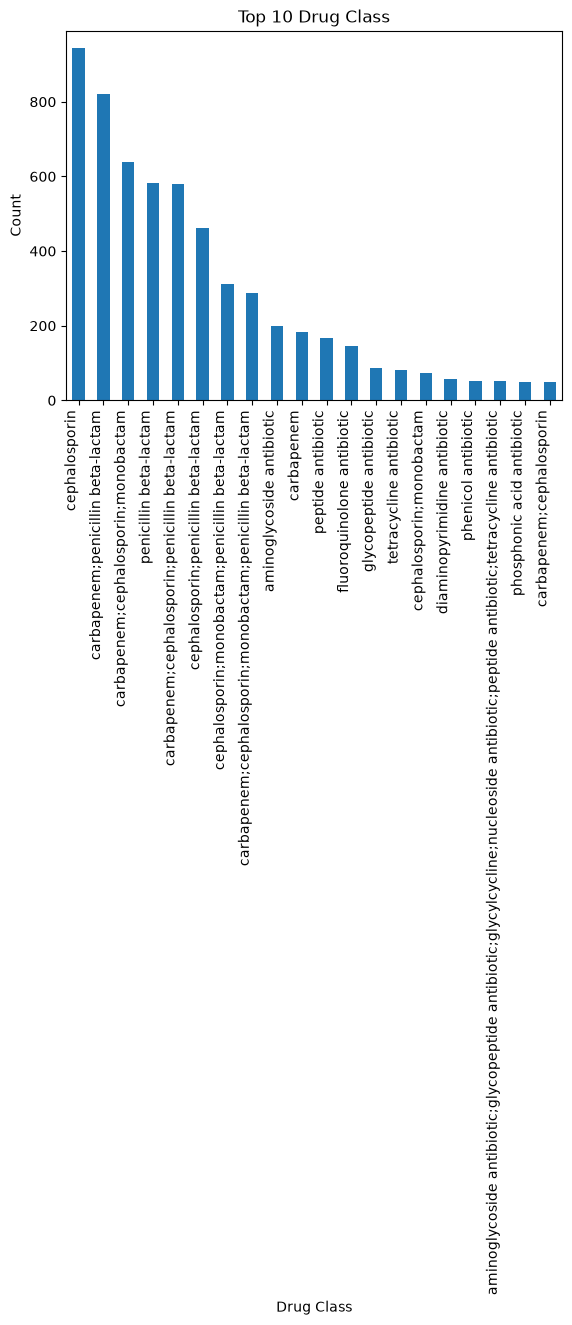

In [69]:
# drawing the drug class count. 

import matplotlib.pyplot as plt

top10 = df["Drug Class"].value_counts().head(20)

top10.plot(kind="bar")

plt.xlabel("Drug Class")
plt.ylabel("Count")
plt.title("Top 10 Drug Class")

plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

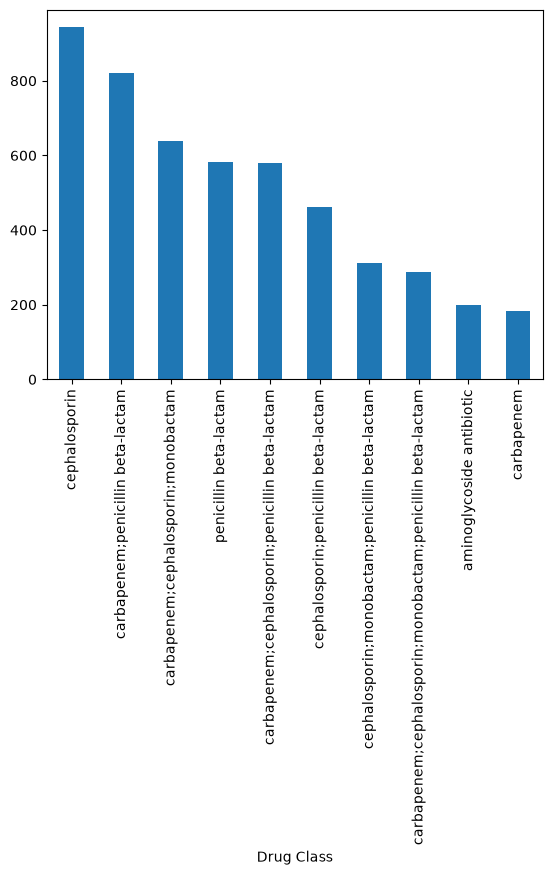

In [66]:
df["Drug Class"].value_counts().head(10).plot(kind="bar")
plt.show()

In [70]:
df["AMR Gene Family"].value_counts()

AMR Gene Family
PDC beta-lactamase                                                       639
OXA beta-lactamase;OXA-51-like beta-lactamase                            383
ADC beta-lactamases pending classification for carbapenemase activity    274
CTX-M beta-lactamase                                                     267
KPC beta-lactamase                                                       229
                                                                        ... 
BlaA beta-lactamase                                                        1
YEM beta-lactamase                                                         1
YOC beta-lactamase                                                         1
YRC beta-lactamase                                                         1
ZOG beta-lactamase                                                         1
Name: count, Length: 540, dtype: int64

/var/folders/32/s903d56x57q5nwqjvf8fy49r0000gn/T/ipykernel_15094/309122586.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


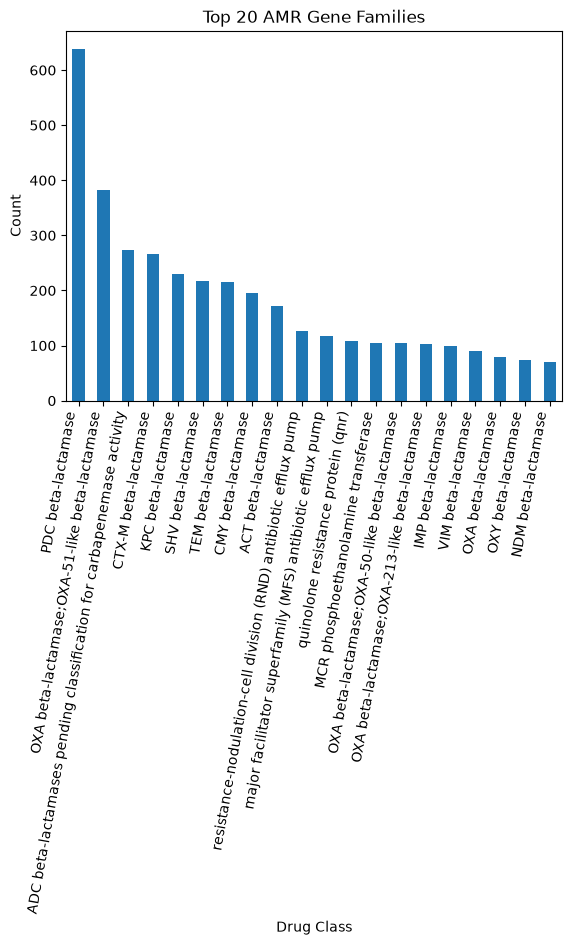

In [75]:
import matplotlib.pyplot as plt

top10 = df["AMR Gene Family"].value_counts().head(20)

top10.plot(kind="bar")

plt.xlabel("Drug Class")
plt.ylabel("Count")
plt.title("Top 20 AMR Gene Families")

plt.xticks(rotation=80, ha="right")
plt.tight_layout()
plt.show()

In [76]:
df["Resistance Mechanism"].value_counts()

Resistance Mechanism
antibiotic inactivation                                                              5245
antibiotic target alteration                                                          580
antibiotic efflux                                                                     296
antibiotic target protection                                                          176
antibiotic target replacement                                                          71
antibiotic efflux;antibiotic target alteration                                         28
reduced permeability to antibiotic                                                     16
antibiotic target alteration;antibiotic target replacement                             10
reduced permeability to antibiotic;resistance by absence                                8
antibiotic efflux;antibiotic target alteration;resistance by absence                    4
antibiotic efflux;reduced permeability to antibiotic                           

/var/folders/32/s903d56x57q5nwqjvf8fy49r0000gn/T/ipykernel_15094/3892144437.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


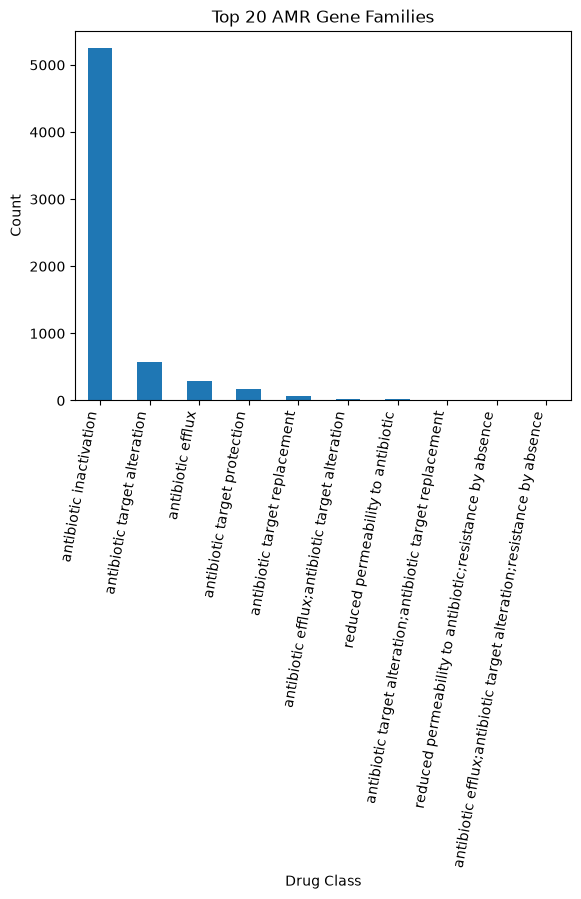

In [78]:
import matplotlib.pyplot as plt

top10 = df["Resistance Mechanism"].value_counts().head(10)

top10.plot(kind="bar")

plt.xlabel("Drug Class")
plt.ylabel("Count")
plt.title("Top 20 AMR Gene Families")

plt.xticks(rotation=80, ha="right")
plt.tight_layout()
plt.show()

In [79]:
#6. Unique values 
df["Drug Class"].unique()

<StringArray>
[                                                                                                                                                                                                                    'lincosamide antibiotic;macrolide antibiotic;streptogramin antibiotic',
                                                                                                                                                                                                                                                                'aminoglycoside antibiotic',
                                                                                                                                                                                                                                     'aminoglycoside antibiotic;fluoroquinolone antibiotic',
                                                                                                                                   

In [80]:
df["Drug Class"].nunique()

161

In [81]:
# 7. Sorting
# alphabetically

df.sort_values("ARO Name")

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
6,ARO:3004628,42613,5361,3327,AAC(2')-IIa,AAC(2')-IIa,BAM16262.1,AB669090.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIa
7,ARO:3003988,40870,3860,2524,AAC(2')-IIb,AAC(2')-IIb,APB03221.1,KX531051.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
...,...,...,...,...,...,...,...,...,...,...,...,...
6432,ARO:3004476,41736,5366,2907,vmlR,vmlR,NP_388442.1,NC_000964.3,Miscellaneous ABC-F subfamily ATP-binding cass...,antibiotic without defined classification;linc...,antibiotic target protection,vmlR
6433,ARO:3003061,39495,62,1223,vph,vph,CAA26235.1,X02393.1,viomycin phosphotransferase,peptide antibiotic,antibiotic inactivation,vph
6436,ARO:3003558,40163,3318,980,y56 beta-lactamase,y56 beta-lactamase,AAX55643.1,AY954728.1,BlaA beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,Yent_y56
6439,ARO:3003063,39497,489,1826,ykkC,ykkC,CAB13166.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkC


In [82]:
df.sort_values("Drug Class")

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
1814,ARO:3003303,39887,2063,111,Escherichia coli gyrB conferring resistance to...,Escherichia coli gyrB conferring resistance to...,BAE77595.1,AP009048.1,aminocoumarin resistant gyrB,aminocoumarin antibiotic,antibiotic target alteration,Ecol_gyrB_AMU
3144,ARO:3002522,38922,8215,1210,novA,novA,AAF67494.2,AF170880.4,ATP-binding cassette (ABC) antibiotic efflux pump,aminocoumarin antibiotic,antibiotic efflux,novA
2735,ARO:3000792,37172,15,387,mdtA,mdtA,AAC75135.2,U00096.1,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic,antibiotic efflux,mdtA
2736,ARO:3000793,37173,215,820,mdtB,mdtB,AAC75136.1,U00096.1,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic,antibiotic efflux,mdtB
2737,ARO:3000794,37174,257,1315,mdtC,mdtC,AAC75137.1,U00096.1,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic,antibiotic efflux,mdtC
...,...,...,...,...,...,...,...,...,...,...,...,...
2939,ARO:3004933,43119,8814,3739,Mycobacterium tuberculosis fabG1 mutation conf...,Mycobacterium tuberculosis fabG1 mutation conf...,NP_215999.1,NC_000962.3,ethionamide resistant fabG1,thioamide antibiotic,antibiotic target alteration,Mtub_fabG1_ETO
2941,ARO:3007811,46597,8855,6035,Mycobacterium tuberculosis fabG1 with mutation...,Mycobacterium tuberculosis fabG1 with mutation...,NP_215999.1,NC_000962.3,prothionamide resistant fabG1,thioamide antibiotic,antibiotic target alteration,Mtub_fabG1_PTO
2973,ARO:3004935,43121,8782,3737,Mycobacterium tuberculosis nudC mutations conf...,Mycobacterium tuberculosis nudC mutations conf...,NP_217715.1,NC_000962.3,ethionamide resistant nudC,thioamide antibiotic,antibiotic target alteration,Mtub_nudC_ETO
2986,ARO:3004955,43141,8884,3736,Mycobacterium tuberculosis Rv0565c mutation co...,Mycobacterium tuberculosis Rv0565c mutation co...,NP_215079.1,NC_000962.3,Ethionamide resistant Rv0565c,thioamide antibiotic,antibiotic target alteration,Mtub_Rv0565_ETO


In [83]:
df.sort_values("Model ID", ascending = False)

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
4520,ARO:3009192,48038,11360,8524,OXY-1-7,OXY-1-7,AWG41961.1,MG028661.1,OXY beta-lactamase,cephalosporin;monobactam;penicillin beta-lactam,antibiotic inactivation,OXY-1-7
990,ARO:3009101,47893,11346,8519,CfiA31,CfiA31,WCS94748.1,OQ379239.1,CfiA beta-lactamase,carbapenem,antibiotic inactivation,CfiA31
989,ARO:3009100,47892,11345,8518,CfiA30,CfiA30,WCS94747.1,OQ379238.1,CfiA beta-lactamase,carbapenem,antibiotic inactivation,CfiA30
988,ARO:3009099,47891,11344,8517,CfiA29,CfiA29,URY98714.1,OL739393.1,CfiA beta-lactamase,carbapenem,antibiotic inactivation,CfiA29
987,ARO:3009098,47890,11343,8516,CfiA28,CfiA28,MBE7399711.1,JADDIJ010000014.1,CfiA beta-lactamase,carbapenem,antibiotic inactivation,CfiA28
...,...,...,...,...,...,...,...,...,...,...,...,...
1631,ARO:3002867,39301,677,5,dfrF,dfrF,AAD01868.1,AF028812.1,trimethoprim resistant dihydrofolate reductase...,diaminopyrimidine antibiotic,antibiotic target replacement,dfrF
5740,ARO:3001109,37489,1393,4,SHV-52,SHV-52,AEJ08681.1,HQ845196.1,SHV beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,SHV-52
1821,ARO:3003390,39974,5413,3,Escherichia coli ompF with mutation conferring...,Escherichia coli ompF with mutation conferring...,AAC74015.1,U00096.3,General Bacterial Porin with reduced permeabil...,carbapenem;cephalosporin;monobactam;penicillin...,reduced permeability to antibiotic,Ecol_ompF_BLA
958,ARO:3002999,39433,1188,2,CblA-1,CblA-1,ACT97415.1,GQ343019.1,CblA beta-lactamase,cephalosporin,antibiotic inactivation,CblA-1


In [85]:
df[
    df["Drug Class"].str.contains("fluoroquinolone", case=False) &
    df["Resistance Mechanism"].str.contains("efflux", case = False)
]


,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
129,ARO:3000753,37133,8212,1368,abeM,abeM,BAD89844.2,AB204810.2,multidrug and toxic compound extrusion (MATE) ...,disinfecting agents and antiseptics;fluoroquin...,antibiotic efflux,abeM
144,ARO:3004574,42490,5314,3278,Acinetobacter baumannii AbaQ,Acinetobacter baumannii AbaQ,ACJ41547.2,CP001182.2,major facilitator superfamily (MFS) antibiotic...,fluoroquinolone antibiotic,antibiotic efflux,Abau_AbaQ
151,ARO:3000216,36355,5485,1104,acrB,acrB,AAC73564.1,U00096.3,resistance-nodulation-cell division (RND) anti...,cephalosporin;disinfecting agents and antisept...,antibiotic efflux,acrB
153,ARO:3000499,36638,333,1445,AcrE,AcrE,AAC76297.1,U00096.1,resistance-nodulation-cell division (RND) anti...,cephalosporin;fluoroquinolone antibiotic;penic...,antibiotic efflux,AcrE
154,ARO:3000502,36641,700,1437,AcrF,AcrF,AAC76298.1,U00096.1,resistance-nodulation-cell division (RND) anti...,cephalosporin;fluoroquinolone antibiotic;penic...,antibiotic efflux,AcrF
...,...,...,...,...,...,...,...,...,...,...,...,...
5836,ARO:3004667,42714,5552,3367,Staphylococcus aureus norA,Staphylococcus aureus norA,BAA14147.1,D90119.1,major facilitator superfamily (MFS) antibiotic...,fluoroquinolone antibiotic,antibiotic efflux,Saur_norA
6178,ARO:3000237,36376,563,826,TolC,TolC,ACN32294.1,FJ768952.1,ATP-binding cassette (ABC) antibiotic efflux p...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,TolC
6191,ARO:3004059,41125,5520,2691,Type A NfxB,Type A NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;cephalosporin;diamino...,antibiotic efflux,Type_A_NfxB
6192,ARO:3004060,41127,5519,2693,Type B NfxB,Type B NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,Type_B_NfxB


In [86]:
#9. string methods 
# converting to lower clase 

df["Drug Class"].str.lower()

0       lincosamide antibiotic;macrolide antibiotic;st...
1                               aminoglycoside antibiotic
2                               aminoglycoside antibiotic
3                               aminoglycoside antibiotic
4                               aminoglycoside antibiotic
                              ...                        
6440    aminoglycoside antibiotic;phenicol antibiotic;...
6441                                        cephalosporin
6442                                   peptide antibiotic
6443                 cephalosporin;penicillin beta-lactam
6444                                           carbapenem
Name: Drug Class, Length: 6445, dtype: str

In [87]:
df["Drug Class"].str.upper()

0       LINCOSAMIDE ANTIBIOTIC;MACROLIDE ANTIBIOTIC;ST...
1                               AMINOGLYCOSIDE ANTIBIOTIC
2                               AMINOGLYCOSIDE ANTIBIOTIC
3                               AMINOGLYCOSIDE ANTIBIOTIC
4                               AMINOGLYCOSIDE ANTIBIOTIC
                              ...                        
6440    AMINOGLYCOSIDE ANTIBIOTIC;PHENICOL ANTIBIOTIC;...
6441                                        CEPHALOSPORIN
6442                                   PEPTIDE ANTIBIOTIC
6443                 CEPHALOSPORIN;PENICILLIN BETA-LACTAM
6444                                           CARBAPENEM
Name: Drug Class, Length: 6445, dtype: str

In [89]:
df[df["Drug Class"].str.startswith("fluo")]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
144,ARO:3004574,42490,5314,3278,Acinetobacter baumannii AbaQ,Acinetobacter baumannii AbaQ,ACJ41547.2,CP001182.2,major facilitator superfamily (MFS) antibiotic...,fluoroquinolone antibiotic,antibiotic efflux,Abau_AbaQ
148,ARO:3003817,40507,4623,2314,Acinetobacter baumannii gyrA conferring resist...,Acinetobacter baumannii gyrA conferring resist...,AJF82744.1,CP010781.1,fluoroquinolone resistant gyrA,fluoroquinolone antibiotic;nybomycin-like anti...,antibiotic target alteration,Abau_gyrA_FLO
150,ARO:3003818,40508,6039,2315,Acinetobacter baumannii parC conferring resist...,Acinetobacter baumannii parC conferring resist...,WP_000202252.1,NZ_CP009257.1,fluoroquinolone resistant parC,fluoroquinolone antibiotic,antibiotic target alteration,Abau_parC_FLO
657,ARO:3000777,37157,6250,153,adeF,adeF,CAJ77856.1,CT025801.2,resistance-nodulation-cell division (RND) anti...,fluoroquinolone antibiotic;tetracycline antibi...,antibiotic efflux,adeF
658,ARO:3000778,37158,6249,1226,adeG,adeG,CAJ77857.1,CT025800.2,resistance-nodulation-cell division (RND) anti...,fluoroquinolone antibiotic;tetracycline antibi...,antibiotic efflux,adeG
...,...,...,...,...,...,...,...,...,...,...,...,...
5836,ARO:3004667,42714,5552,3367,Staphylococcus aureus norA,Staphylococcus aureus norA,BAA14147.1,D90119.1,major facilitator superfamily (MFS) antibiotic...,fluoroquinolone antibiotic,antibiotic efflux,Saur_norA
5837,ARO:3003312,39896,6038,212,Staphylococcus aureus parC conferring resistan...,Staphylococcus aureus parC conferring resistan...,WP_001289569.1,NC_002951.2,fluoroquinolone resistant parC,fluoroquinolone antibiotic,antibiotic target alteration,Saur_parC_FLO
5839,ARO:3003315,39899,5400,335,Staphylococcus aureus parE conferring resistan...,Staphylococcus aureus parE conferring resistan...,CAG40364.1,BX571856.1,fluoroquinolone resistant parE,fluoroquinolone antibiotic,antibiotic target alteration,Saur_parE_FLO
5851,ARO:3003311,39895,6037,660,Streptococcus pneumoniae parC conferring resis...,Streptococcus pneumoniae parC conferring resis...,NP_358351.1,NC_003098.1,fluoroquinolone resistant parC,fluoroquinolone antibiotic,antibiotic target alteration,Spne_parC_FLO


In [91]:
df[df["Drug Class"].str.endswith("antibiotic")]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id
...,...,...,...,...,...,...,...,...,...,...,...,...
6434,ARO:3007843,46632,8888,6065,VRA-F,VRA-F,WP_323056190.1,NZ_JAYEPV010000001.1,ATP-binding cassette (ABC) antibiotic efflux pump,glycopeptide antibiotic,antibiotic efflux,VRA-F
6437,ARO:3005040,43238,6076,3783,YajC,YajC,TKW44661.1,VAOQ01003483.1,resistance-nodulation-cell division (RND) anti...,cephalosporin;disinfecting agents and antisept...,antibiotic efflux,YajC
6439,ARO:3003063,39497,489,1826,ykkC,ykkC,CAB13166.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkC
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD


In [93]:
df[df["Drug Class"].str.contains("macro")]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb
126,ARO:3007669,46449,8732,6002,aadT,aadT,AMD83542.1,KT852971.1,major facilitator superfamily (MFS) antibiotic...,disinfecting agents and antiseptics;macrolide ...,antibiotic efflux,aadT
130,ARO:3000768,37148,4569,593,abeS,abeS,ACJ59254.1,CP001172.1,small multidrug resistance (SMR) antibiotic ef...,aminocoumarin antibiotic;macrolide antibiotic,antibiotic efflux,abeS
147,ARO:3004577,42497,5144,3280,Acinetobacter baumannii AmvA,Acinetobacter baumannii AmvA,ACQ82816.1,FJ911554.1,major facilitator superfamily (MFS) antibiotic...,disinfecting agents and antiseptics;macrolide ...,antibiotic efflux,Abau_AmvA
660,ARO:3000780,37160,5374,1471,adeI,adeI,ACJ41739.1,CP001182.2,resistance-nodulation-cell division (RND) anti...,carbapenem;cephalosporin;diaminopyrimidine ant...,antibiotic efflux,adeI
...,...,...,...,...,...,...,...,...,...,...,...,...
6174,ARO:3002827,39261,158,1997,tlrC,tlrC,AAA26832.1,M57437.1,Miscellaneous ABC-F subfamily ATP-binding cass...,lincosamide antibiotic;macrolide antibiotic,antibiotic target protection,tlrC
6178,ARO:3000237,36376,563,826,TolC,TolC,ACN32294.1,FJ768952.1,ATP-binding cassette (ABC) antibiotic efflux p...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,TolC
6179,ARO:3007759,46541,8750,6019,Treponema pallidum 23S rRNA with mutation conf...,Treponema pallidum 23S rRNA with mutation conf...,NaN,NR_076156.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Tpal_23S_ERY
6191,ARO:3004059,41125,5520,2691,Type A NfxB,Type A NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;cephalosporin;diamino...,antibiotic efflux,Type_A_NfxB


In [94]:
df["ARO Name"].str.len()

0       54
1       10
2       10
3       10
4       10
        ..
6440     4
6441     5
6442     4
6443     5
6444     5
Name: ARO Name, Length: 6445, dtype: int64

In [96]:
# 10 Create new columns
df["Name length"] = df["ARO Name"].str.len()
df

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,10
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,4
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,4
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,5


In [98]:
df["Upper"] = df["ARO Name"].str.upper()
df

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10,AAC(2')-IB
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,10,AAC(2')-IC
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,10,AAC(2')-ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,4,YKKD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,4,YOJI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,5,YRC-1


In [106]:
# 11.Rename columns
df.rename(columns = {"Name length": "ARO Name length"})




,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,ARO Name length,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10,AAC(2')-IB
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,10,AAC(2')-IC
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,10,AAC(2')-ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,4,YKKD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,4,YOJI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,5,YRC-1


In [105]:
df.rename(columns={"ARO Name": "Gene Name"})

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,Gene Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10,AAC(2')-IB
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,10,AAC(2')-IC
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,10,AAC(2')-ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,4,YKKD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,4,YOJI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,5,YRC-1


In [107]:
df.rename(columns = {"Upper": "ARO Name Upper"})

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,ARO Name Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10,AAC(2')-IB
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,10,AAC(2')-IC
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,10,AAC(2')-ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,4,YKKD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,4,YOJI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,5,YRC-1


In [111]:
# 12. Drop columns 
df.drop(columns=["Upper"])

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,10
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,4
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,4
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,5


In [114]:
df.drop(columns = ["Name length"])

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,AAC(2')-IB
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,AAC(2')-IC
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,AAC(2')-ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,YKKD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,YOJI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,YRC-1


In [115]:
#13. Missing vlaues 
# Count missing values 

df.isna().sum()

ARO Accession            0
CVTERM ID                0
Model Sequence ID        0
Model ID                 0
Model Name               0
ARO Name                 0
Protein Accession       87
DNA Accession            0
AMR Gene Family          0
Drug Class               0
Resistance Mechanism     0
CARD Short Name          0
Name length              0
Upper                    0
dtype: int64

In [116]:
df.fillna(0)

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10,AAC(2')-IB
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,10,AAC(2')-IC
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,10,AAC(2')-ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,4,YKKD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,4,YOJI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,5,YRC-1


In [117]:
df.isna().sum()

ARO Accession            0
CVTERM ID                0
Model Sequence ID        0
Model ID                 0
Model Name               0
ARO Name                 0
Protein Accession       87
DNA Accession            0
AMR Gene Family          0
Drug Class               0
Resistance Mechanism     0
CARD Short Name          0
Name length              0
Upper                    0
dtype: int64

In [122]:
df_nona = df.dropna(subset = ["Protein Accession"])

In [123]:
df_nona.isna().sum()

ARO Accession           0
CVTERM ID               0
Model Sequence ID       0
Model ID                0
Model Name              0
ARO Name                0
Protein Accession       0
DNA Accession           0
AMR Gene Family         0
Drug Class              0
Resistance Mechanism    0
CARD Short Name         0
Name length             0
Upper                   0
dtype: int64

In [124]:
df.duplicated().sum()

np.int64(0)

In [128]:
df["ARO Name"].duplicated().sum()

np.int64(5)

# 15. Grouping (Very important)

In [131]:
# count genes in each drug class 
df.groupby("Drug Class").size()

Drug Class
aminocoumarin antibiotic                                                                                                                                                                                                                                                                                                 9
aminocoumarin antibiotic;aminoglycoside antibiotic                                                                                                                                                                                                                                                                       3
aminocoumarin antibiotic;aminoglycoside antibiotic;carbapenem;cephalosporin;diaminopyrimidine antibiotic;disinfecting agents and antiseptics;fluoroquinolone antibiotic;macrolide antibiotic;monobactam;penicillin beta-lactam;peptide antibiotic;phenicol antibiotic;sulfonamide antibiotic;tetracycline antibiotic     1
aminocoumarin antibiotic;aminoglycoside anti

In [132]:
#Drug class in each resistance mechanism

df.groupby("Resistance Mechanism")["Drug Class"].count()

Resistance Mechanism
antibiotic efflux                                                                     296
antibiotic efflux;antibiotic target alteration                                         28
antibiotic efflux;antibiotic target alteration;reduced permeability to antibiotic       2
antibiotic efflux;antibiotic target alteration;resistance by absence                    4
antibiotic efflux;reduced permeability to antibiotic                                    4
antibiotic inactivation                                                              5245
antibiotic inactivation;antibiotic target alteration                                    2
antibiotic target alteration                                                          580
antibiotic target alteration;antibiotic target replacement                             10
antibiotic target protection                                                          176
antibiotic target replacement                                                  

In [133]:
df.groupby("Drug Class")["Resistance Mechanism"].count()

Drug Class
aminocoumarin antibiotic                                                                                                                                                                                                                                                                                                 9
aminocoumarin antibiotic;aminoglycoside antibiotic                                                                                                                                                                                                                                                                       3
aminocoumarin antibiotic;aminoglycoside antibiotic;carbapenem;cephalosporin;diaminopyrimidine antibiotic;disinfecting agents and antiseptics;fluoroquinolone antibiotic;macrolide antibiotic;monobactam;penicillin beta-lactam;peptide antibiotic;phenicol antibiotic;sulfonamide antibiotic;tetracycline antibiotic     1
aminocoumarin antibiotic;aminoglycoside anti

In [136]:
#16. Query 
df.query("`Model ID` > 5000")

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
48,ARO:3007204,45948,8509,5817,AAC(6')-Iap,AAC(6')-Iap,BCD41405.1,LC536747.1,AAC(6'),aminoglycoside antibiotic,antibiotic inactivation,AAC(6')-Iap,11,AAC(6')-IAP
59,ARO:3007770,46553,8755,6020,aac(6')-Ib-cr10,aac(6')-Ib-cr10,WP_124042715.1,NG_067968.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr10,15,AAC(6')-IB-CR10
60,ARO:3007771,46554,8756,6021,aac(6')-Ib-cr11,aac(6')-Ib-cr11,WP_159241551.1,NG_067969.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr11,15,AAC(6')-IB-CR11
126,ARO:3007669,46449,8732,6002,aadT,aadT,AMD83542.1,KT852971.1,major facilitator superfamily (MFS) antibiotic...,disinfecting agents and antiseptics;macrolide ...,antibiotic efflux,aadT,4,AADT
158,ARO:3007883,46675,10128,7301,ACT-100,ACT-100,UHK14157.1,OL794654.1,ACT beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,ACT-100,7,ACT-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6434,ARO:3007843,46632,8888,6065,VRA-F,VRA-F,WP_323056190.1,NZ_JAYEPV010000001.1,ATP-binding cassette (ABC) antibiotic efflux pump,glycopeptide antibiotic,antibiotic efflux,VRA-F,5,VRA-F
6435,ARO:3007435,46193,8652,5933,WUS-1,WUS-1,UPP01678.1,OL872181.1,WUS beta-lactamase,carbapenem;penicillin beta-lactam,antibiotic inactivation,WUS-1,5,WUS-1
6438,ARO:3007005,45467,8098,5723,YEM-1,YEM-1,WP_004874166.1,NG_070759.1,YEM beta-lactamase,carbapenem,antibiotic inactivation,YEM-1,5,YEM-1
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,5,YOC-1


In [137]:
# 17. Random sample 

df.sample(10)

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
2053,ARO:3005698,44160,7037,4662,GOB-50,GOB-50,WP_078675023.1,NG_068014.1,GOB beta-lactamase,carbapenem;cephalosporin;penicillin beta-lactam,antibiotic inactivation,GOB-50,6,GOB-50
705,ARO:3002669,39069,4749,903,APH(2'')-Ig,APH(2'')-Ig,AGV10818.1,CP004067.1,APH(2''),aminoglycoside antibiotic,antibiotic inactivation,APH(2'')-Ig,11,APH(2'')-IG
5403,ARO:3002764,39198,214,484,QnrB49,QnrB49,AFD54601.1,JQ582718.1,quinolone resistance protein (qnr),fluoroquinolone antibiotic,antibiotic target protection,QnrB49,6,QNRB49
715,ARO:3002645,39045,159,954,APH(3')-IIb,APH(3')-IIb,CAA62365.1,X90856.1,APH(3'),aminoglycoside antibiotic,antibiotic inactivation,APH(3')-IIb,11,APH(3')-IIB
2320,ARO:3002324,38724,1971,494,KPC-14,KPC-14,AFV48348.1,JX524191.1,KPC beta-lactamase,carbapenem;cephalosporin;monobactam;penicillin...,antibiotic inactivation,KPC-14,6,KPC-14
2511,ARO:3002997,39431,775,901,LCR-1,LCR-1,CAA40146.1,X56809.1,LCR beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,LCR-1,5,LCR-1
5624,ARO:3001075,37455,8247,1739,SHV-16,SHV-16,AAC98092.2,AF072684.2,SHV beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,SHV-16,6,SHV-16
1815,ARO:3004126,41252,8289,2788,Escherichia coli LamB,Escherichia coli LamB,BAB38442.1,BA000007.3,Sugar Porin (SP),fluoroquinolone antibiotic;tetracycline antibi...,reduced permeability to antibiotic;resistance ...,Ecol_LamB,21,ESCHERICHIA COLI LAMB
102,ARO:3002612,39012,57,149,aadA12,aadA12,ACJ47200.1,FJ381668.1,ANT(3''),aminoglycoside antibiotic,antibiotic inactivation,aadA12,6,AADA12
2003,ARO:3008192,46984,10437,7610,GIM-3,GIM-3,BDR24829.1,LC727552.1,GIM beta-lactamase,carbapenem;cephalosporin;monobactam;penicillin...,antibiotic inactivation,GIM-3,5,GIM-3


In [139]:
df.to_csv("card_filtered.csv", index  = False)

## Challenge Exercises (Do These Without Looking Up the Answer)

1. Find all genes that confer fluoroquinolone resistance.
2. Count how many unique drug classes exist.
3. Find the 10 most common gene families.
4. Show only ARO Name, Drug Class, and Resistance Mechanism.
5. Find all rows where Protein Accession is missing.
6. Find genes whose ARO Name contains "bla".
7. Sort the table by ARO Name.
8. Count how many genes belong to each Resistance Mechanism.
9. Create a new column containing the length of each ARO Name.
10. Find all rows where the drug class contains aminoglycoside.

These exercises cover about 80–90% of the pandas operations you'll use in day-to-day bioinformatics (filtering, selecting, sorting, grouping, string processing, and handling missing data). Once you're comfortable with these, the next major topic is merging (merge), joining, concatenating, pivot tables, and applying custom functions (apply), which are the core tools for integrating biological datasets.

In [141]:
#1. Find all genes that confer fluoroquinolone resistance.

df[df["Drug Class"].str.contains("fluoroquinolone", case = False, na = False)]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
58,ARO:3002547,38947,6152,1678,AAC(6')-Ib-cr1,AAC(6')-Ib-cr1,WP_071846215.1,NG_052213.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr1,14,AAC(6')-IB-CR1
59,ARO:3007770,46553,8755,6020,aac(6')-Ib-cr10,aac(6')-Ib-cr10,WP_124042715.1,NG_067968.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr10,15,AAC(6')-IB-CR10
60,ARO:3007771,46554,8756,6021,aac(6')-Ib-cr11,aac(6')-Ib-cr11,WP_159241551.1,NG_067969.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,aac(6')-Ib-cr11,15,AAC(6')-IB-CR11
61,ARO:3005112,43327,8752,3840,AAC(6')-Ib-cr3,AAC(6')-Ib-cr3,WP_071766621.1,NG_052123.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr3,14,AAC(6')-IB-CR3
62,ARO:3005114,43329,8753,3841,AAC(6')-Ib-cr4,AAC(6')-Ib-cr4,WP_065187000.1,NG_052463.1,AAC(6');AAC(6')-Ib-cr,aminoglycoside antibiotic;fluoroquinolone anti...,antibiotic inactivation,AAC(6')-Ib-cr4,14,AAC(6')-IB-CR4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6191,ARO:3004059,41125,5520,2691,Type A NfxB,Type A NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;cephalosporin;diamino...,antibiotic efflux,Type_A_NfxB,11,TYPE A NFXB
6192,ARO:3004060,41127,5519,2693,Type B NfxB,Type B NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,Type_B_NfxB,11,TYPE B NFXB
6194,ARO:3003305,39889,5887,2148,Ureaplasma urealyticum gyrB conferring resista...,Ureaplasma urealyticum gyrB conferring resista...,WP_004025678.1,NC_011374.1,fluoroquinolone resistant gyrB,aminocoumarin antibiotic;fluoroquinolone antib...,antibiotic target alteration,Uure_gyrB_FLO,69,UREAPLASMA UREALYTICUM GYRB CONFERRING RESISTA...
6195,ARO:3003309,39893,5888,2104,Ureaplasma urealyticum parC conferring resista...,Ureaplasma urealyticum parC conferring resista...,WP_010891786.1,NC_002162.1,fluoroquinolone resistant parC,fluoroquinolone antibiotic,antibiotic target alteration,Uure_parC_FLO,69,UREAPLASMA UREALYTICUM PARC CONFERRING RESISTA...


In [144]:
# 2. Count how many unique drug classes exist.
df["Drug Class"].unique()

<StringArray>
[                                                                                                                                                                                                                    'lincosamide antibiotic;macrolide antibiotic;streptogramin antibiotic',
                                                                                                                                                                                                                                                                'aminoglycoside antibiotic',
                                                                                                                                                                                                                                     'aminoglycoside antibiotic;fluoroquinolone antibiotic',
                                                                                                                                   

In [145]:
len(df["Drug Class"].unique())

161

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6445 entries, 0 to 6444
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ARO Accession         6445 non-null   str  
 1   CVTERM ID             6445 non-null   int64
 2   Model Sequence ID     6445 non-null   int64
 3   Model ID              6445 non-null   int64
 4   Model Name            6445 non-null   str  
 5   ARO Name              6445 non-null   str  
 6   Protein Accession     6358 non-null   str  
 7   DNA Accession         6445 non-null   str  
 8   AMR Gene Family       6445 non-null   str  
 9   Drug Class            6445 non-null   str  
 10  Resistance Mechanism  6445 non-null   str  
 11  CARD Short Name       6445 non-null   str  
 12  Name length           6445 non-null   int64
 13  Upper                 6445 non-null   str  
dtypes: int64(4), str(10)
memory usage: 705.1 KB


In [154]:
# Find 10 most common AMR gene families

df["AMR Gene Family"].value_counts().head(10)

AMR Gene Family
PDC beta-lactamase                                                       639
OXA beta-lactamase;OXA-51-like beta-lactamase                            383
ADC beta-lactamases pending classification for carbapenemase activity    274
CTX-M beta-lactamase                                                     267
KPC beta-lactamase                                                       229
SHV beta-lactamase                                                       218
TEM beta-lactamase                                                       216
CMY beta-lactamase                                                       195
ACT beta-lactamase                                                       172
resistance-nodulation-cell division (RND) antibiotic efflux pump         127
Name: count, dtype: int64

In [157]:
# Challenge 4. Show only the columns ARO Name, Drug Class, and Resistance Mechanism


df[["ARO Name", "Drug Class", "Resistance Mechanism"]]


,ARO Name,Drug Class,Resistance Mechanism
0,23S rRNA (adenine(2058)-N(6))-methyltransferas...,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration
1,AAC(2')-Ia,aminoglycoside antibiotic,antibiotic inactivation
2,AAC(2')-Ib,aminoglycoside antibiotic,antibiotic inactivation
3,AAC(2')-Ic,aminoglycoside antibiotic,antibiotic inactivation
4,AAC(2')-Id,aminoglycoside antibiotic,antibiotic inactivation
...,...,...,...
6440,ykkD,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux
6441,YOC-1,cephalosporin,antibiotic inactivation
6442,YojI,peptide antibiotic,antibiotic efflux
6443,YRC-1,cephalosporin;penicillin beta-lactam,antibiotic inactivation


In [160]:
# Challenge 5: Find all rows where Protein Accession is missing.
df.isna().count()

ARO Accession           6445
CVTERM ID               6445
Model Sequence ID       6445
Model ID                6445
Model Name              6445
ARO Name                6445
Protein Accession       6445
DNA Accession           6445
AMR Gene Family         6445
Drug Class              6445
Resistance Mechanism    6445
CARD Short Name         6445
Name length             6445
Upper                   6445
dtype: int64

In [161]:
df.isna().sum()

ARO Accession            0
CVTERM ID                0
Model Sequence ID        0
Model ID                 0
Model Name               0
ARO Name                 0
Protein Accession       87
DNA Accession            0
AMR Gene Family          0
Drug Class               0
Resistance Mechanism     0
CARD Short Name          0
Name length              0
Upper                    0
dtype: int64

In [164]:
df[df["Protein Accession"].isna()]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
861,ARO:3003504,40106,3268,2143,Borreliella burgdorferi 16S rRNA mutation conf...,Borreliella burgdorferi 16S rRNA mutation conf...,NaN,NR_044732.2,16s rRNA with mutation conferring resistance t...,aminoglycoside antibiotic;glycopeptide antibio...,antibiotic target alteration,Bbur_16S_GEN,77,BORRELIELLA BURGDORFERI 16S RRNA MUTATION CONF...
862,ARO:3003503,40105,8691,2127,Borreliella burgdorferi 16S rRNA mutation conf...,Borreliella burgdorferi 16S rRNA mutation conf...,NaN,NZ_ABCW02000003.1,16s rRNA with mutation conferring resistance t...,aminoglycoside antibiotic;glycopeptide antibio...,antibiotic target alteration,Bbur_16S_KAN,76,BORRELIELLA BURGDORFERI 16S RRNA MUTATION CONF...
863,ARO:3003502,40104,3267,2154,Borreliella burgdorferi 16S rRNA mutation conf...,Borreliella burgdorferi 16S rRNA mutation conf...,NaN,NR_044732.2,16s rRNA with mutation conferring resistance t...,aminoglycoside antibiotic;glycopeptide antibio...,antibiotic target alteration,Bbur_16S_SPT,80,BORRELIELLA BURGDORFERI 16S RRNA MUTATION CONF...
866,ARO:3004133,41260,4183,2833,Brachyspira hyodysenteriae 23S rRNA with mutat...,Brachyspira hyodysenteriae 23S rRNA with mutat...,NaN,NZ_CP015910.2,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Bhyo_23S_TYL,82,BRACHYSPIRA HYODYSENTERIAE 23S RRNA WITH MUTAT...
880,ARO:3004546,42445,5105,3252,Campylobacter jejuni 23S rRNA with mutation co...,Campylobacter jejuni 23S rRNA with mutation co...,NaN,NR_076226.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Cjej_23S_ERY,81,CAMPYLOBACTER JEJUNI 23S RRNA WITH MUTATION CO...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5849,ARO:3004181,41334,4171,2826,Streptococcus pneumoniae 23S rRNA mutation con...,Streptococcus pneumoniae 23S rRNA mutation con...,NaN,NZ_CP018138.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Spne_23S_MULT,109,STREPTOCOCCUS PNEUMONIAE 23S RRNA MUTATION CON...
5850,ARO:3004170,41320,5408,2817,Streptococcus pneumoniae 23S rRNA with mutatio...,Streptococcus pneumoniae 23S rRNA with mutatio...,NaN,NZ_CP018138.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Spne_23S_MAC,94,STREPTOCOCCUS PNEUMONIAE 23S RRNA WITH MUTATIO...
5858,ARO:3004171,41322,4163,2818,Streptomyces ambofaciens 23S rRNA with mutatio...,Streptomyces ambofaciens 23S rRNA with mutatio...,NaN,NZ_CP012949.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Samb_23S_MAC,94,STREPTOMYCES AMBOFACIENS 23S RRNA WITH MUTATIO...
6166,ARO:3005083,43292,6116,3818,Thermus thermophilus 23s rRNA conferring resis...,Thermus thermophilus 23s rRNA conferring resis...,NaN,AE017221.1,23S rRNA with mutation conferring resistance t...,glycopeptide antibiotic;lincosamide antibiotic...,antibiotic target alteration,Tthe_23S_PLM,80,THERMUS THERMOPHILUS 23S RRNA CONFERRING RESIS...


In [166]:
# Challenge 6: Find all rows where the ARO Name contains "bla" (case-insensitive). 

df[df["ARO Name"].str.contains("bla", case = False)]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
851,ARO:3007182,45921,8481,5800,blaC,blaC,CCP44842.1,AL123456.3,class A Mycobacterium tuberculosis bla beta-la...,cephalosporin;penicillin beta-lactam,antibiotic inactivation,blaC,4,BLAC
852,ARO:3003562,40169,3317,395,blaF,blaF,AAA19882.1,L25634.1,blaF family beta-lactamase,penicillin beta-lactam,antibiotic inactivation,blaF,4,BLAF
853,ARO:3000160,36299,4710,1374,blaI,blaI,ABU39978.1,EF540343.1,BlaZ beta-lactamase,penicillin beta-lactam,antibiotic inactivation,blaI,4,BLAI
854,ARO:3000217,36356,4663,2063,blaR1,blaR1,ABU39979.1,EF540343.1,BlaZ beta-lactamase,penicillin beta-lactam,antibiotic inactivation,blaR1,5,BLAR1
855,ARO:3005111,43326,6151,3839,blaS1,blaS1,AAP97895.1,AY332268.1,blaS,cephalosporin;penicillin beta-lactam,antibiotic inactivation,blaS1,5,BLAS1
4590,ARO:3000621,36963,4586,726,PC1 beta-lactamase (blaZ),PC1 beta-lactamase (blaZ),ABX30738.1,CP000732.1,BlaZ beta-lactamase,penicillin beta-lactam,antibiotic inactivation,PC1_blaZ,25,PC1 BETA-LACTAMASE (BLAZ)


In [171]:
# Challenge 7: Sort the DataFrame by ARO Name in alphabetical order.

df.sort_values("ARO Name")

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
6,ARO:3004628,42613,5361,3327,AAC(2')-IIa,AAC(2')-IIa,BAM16262.1,AB669090.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIa,11,AAC(2')-IIA
7,ARO:3003988,40870,3860,2524,AAC(2')-IIb,AAC(2')-IIb,APB03221.1,KX531051.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIb,11,AAC(2')-IIB
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10,AAC(2')-IB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6432,ARO:3004476,41736,5366,2907,vmlR,vmlR,NP_388442.1,NC_000964.3,Miscellaneous ABC-F subfamily ATP-binding cass...,antibiotic without defined classification;linc...,antibiotic target protection,vmlR,4,VMLR
6433,ARO:3003061,39495,62,1223,vph,vph,CAA26235.1,X02393.1,viomycin phosphotransferase,peptide antibiotic,antibiotic inactivation,vph,3,VPH
6436,ARO:3003558,40163,3318,980,y56 beta-lactamase,y56 beta-lactamase,AAX55643.1,AY954728.1,BlaA beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,Yent_y56,18,Y56 BETA-LACTAMASE
6439,ARO:3003063,39497,489,1826,ykkC,ykkC,CAB13166.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkC,4,YKKC


In [173]:
df.sort_values("ARO Name", ascending=True)



,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Name length,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,54,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
6,ARO:3004628,42613,5361,3327,AAC(2')-IIa,AAC(2')-IIa,BAM16262.1,AB669090.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIa,11,AAC(2')-IIA
7,ARO:3003988,40870,3860,2524,AAC(2')-IIb,AAC(2')-IIb,APB03221.1,KX531051.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-IIb,11,AAC(2')-IIB
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,10,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,10,AAC(2')-IB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6432,ARO:3004476,41736,5366,2907,vmlR,vmlR,NP_388442.1,NC_000964.3,Miscellaneous ABC-F subfamily ATP-binding cass...,antibiotic without defined classification;linc...,antibiotic target protection,vmlR,4,VMLR
6433,ARO:3003061,39495,62,1223,vph,vph,CAA26235.1,X02393.1,viomycin phosphotransferase,peptide antibiotic,antibiotic inactivation,vph,3,VPH
6436,ARO:3003558,40163,3318,980,y56 beta-lactamase,y56 beta-lactamase,AAX55643.1,AY954728.1,BlaA beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,Yent_y56,18,Y56 BETA-LACTAMASE
6439,ARO:3003063,39497,489,1826,ykkC,ykkC,CAB13166.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkC,4,YKKC


In [178]:
# Challenge 8: Count how many genes belong to each Resistance Mechanism

df.value_counts("Resistance Mechanism")

Resistance Mechanism
antibiotic inactivation                                                              5245
antibiotic target alteration                                                          580
antibiotic efflux                                                                     296
antibiotic target protection                                                          176
antibiotic target replacement                                                          71
antibiotic efflux;antibiotic target alteration                                         28
reduced permeability to antibiotic                                                     16
antibiotic target alteration;antibiotic target replacement                             10
reduced permeability to antibiotic;resistance by absence                                8
antibiotic efflux;antibiotic target alteration;resistance by absence                    4
antibiotic efflux;reduced permeability to antibiotic                           

In [179]:
df["Resistance Mechanism"].value_counts()

Resistance Mechanism
antibiotic inactivation                                                              5245
antibiotic target alteration                                                          580
antibiotic efflux                                                                     296
antibiotic target protection                                                          176
antibiotic target replacement                                                          71
antibiotic efflux;antibiotic target alteration                                         28
reduced permeability to antibiotic                                                     16
antibiotic target alteration;antibiotic target replacement                             10
reduced permeability to antibiotic;resistance by absence                                8
antibiotic efflux;antibiotic target alteration;resistance by absence                    4
antibiotic efflux;reduced permeability to antibiotic                           

In [191]:
#Challenge 9: Create a new column called "Name Length" that contains the length of each ARO Name

d




,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Upper
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,AAC(2')-IA
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,AAC(2')-IB
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,AAC(2')-IC
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,AAC(2')-ID
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,YKKD
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,YOC-1
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,YOJI
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,YRC-1


In [193]:
df["Name length"] = df["ARO Name"].str.len()
df

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Upper,Name length
0,ARO:3005099,43314,6143,3831,23S rRNA (adenine(2058)-N(6))-methyltransferas...,23S rRNA (adenine(2058)-N(6))-methyltransferas...,AAB60941.1,AF002716.1,Erm 23S ribosomal RNA methyltransferase,lincosamide antibiotic;macrolide antibiotic;st...,antibiotic target alteration,Spyo_ErmA_MLSb,23S RRNA (ADENINE(2058)-N(6))-METHYLTRANSFERAS...,54
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,AAC(2')-IA,10
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,AAC(2')-IB,10
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,AAC(2')-IC,10
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,AAC(2')-ID,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440,ARO:3003064,39498,536,350,ykkD,ykkD,CAB13167.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkD,YKKD,4
6441,ARO:3009096,47888,11341,8514,YOC-1,YOC-1,QIU91361.1,CP050811.1,YOC beta-lactamase,cephalosporin,antibiotic inactivation,YOC-1,YOC-1,5
6442,ARO:3003952,40722,5261,2424,YojI,YojI,AAC75271.1,U00096.3,ATP-binding cassette (ABC) antibiotic efflux pump,peptide antibiotic,antibiotic efflux,YojI,YOJI,4
6443,ARO:3005035,43233,6072,3779,YRC-1,YRC-1,ABA70720.1,DQ185144.1,YRC beta-lactamase,cephalosporin;penicillin beta-lactam,antibiotic inactivation,YRC-1,YRC-1,5


In [201]:
#Find all rows where the Drug Class contains "aminoglycoside" (case-insensitive)

df.str.contains("aminoglycosides")




0       False
1       False
2       False
3       False
4       False
        ...  
6440    False
6441    False
6442    False
6443    False
6444    False
Name: Drug Class, Length: 6445, dtype: bool

In [209]:
df[df["Drug Class"].str.contains("aminoglycoside")]

,ARO Accession,CVTERM ID,Model Sequence ID,Model ID,Model Name,ARO Name,Protein Accession,DNA Accession,AMR Gene Family,Drug Class,Resistance Mechanism,CARD Short Name,Upper,Name length
1,ARO:3002523,38923,8144,1781,AAC(2')-Ia,AAC(2')-Ia,AAA03550.1,L06156.2,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ia,AAC(2')-IA,10
2,ARO:3002524,38924,85,746,AAC(2')-Ib,AAC(2')-Ib,AAC44793.1,U41471.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ib,AAC(2')-IB,10
3,ARO:3002525,38925,4719,1246,AAC(2')-Ic,AAC(2')-Ic,CCP42991.1,AL123456.3,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ic,AAC(2')-IC,10
4,ARO:3002526,38926,228,1415,AAC(2')-Id,AAC(2')-Id,AAB41701.1,U72743.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Id,AAC(2')-ID,10
5,ARO:3002527,38927,5510,2832,AAC(2')-Ie,AAC(2')-Ie,CAC32082.1,AL583926.1,AAC(2'),aminoglycoside antibiotic,antibiotic inactivation,AAC(2')-Ie,AAC(2')-IE,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5829,ARO:3004572,42486,5623,3276,Staphylococcus aureus LmrS,Staphylococcus aureus LmrS,AAW38464.1,CP000046.1,major facilitator superfamily (MFS) antibiotic...,aminoglycoside antibiotic;diaminopyrimidine an...,antibiotic efflux,Saur_LmrS,STAPHYLOCOCCUS AUREUS LMRS,26
6178,ARO:3000237,36376,563,826,TolC,TolC,ACN32294.1,FJ768952.1,ATP-binding cassette (ABC) antibiotic efflux p...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,TolC,TOLC,4
6192,ARO:3004060,41127,5519,2693,Type B NfxB,Type B NfxB,AAG07988.1,AE004091.2,resistance-nodulation-cell division (RND) anti...,aminocoumarin antibiotic;aminoglycoside antibi...,antibiotic efflux,Type_B_NfxB,TYPE B NFXB,11
6439,ARO:3003063,39497,489,1826,ykkC,ykkC,CAB13166.1,AL009126.1,small multidrug resistance (SMR) antibiotic ef...,aminoglycoside antibiotic;phenicol antibiotic;...,antibiotic efflux,ykkC,YKKC,4
